BLSTM

X_train shape: (2287, 60, 5), y_train shape: (2287,)
X_test shape: (572, 60, 5), y_test shape: (572,)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 60, 100)             │          22,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 60, 100)             │          60,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 100)                 │          60,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 143,301 (559.77 KB)

 Trainable params: 143,301 (559.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.0284 - val_loss: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0020 - val_loss: 9.4680e-04
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0017 - val_loss: 6.9006e-04
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0018 - val_loss: 5.9009e-04
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0019 - val_loss: 5.2429e-04
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0020 - val_loss: 5.5360e-04
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0013 - val_loss: 5.7791e-04
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0016 - val_loss: 5.4831e-04
Epoch 9/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0013 - val_loss: 6.0134e-04
Epoch 10/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0013 - val_loss: 7.1992e-04
Epoch 11/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0013 - val_loss: 3.8688e-04
Epoch 12/10

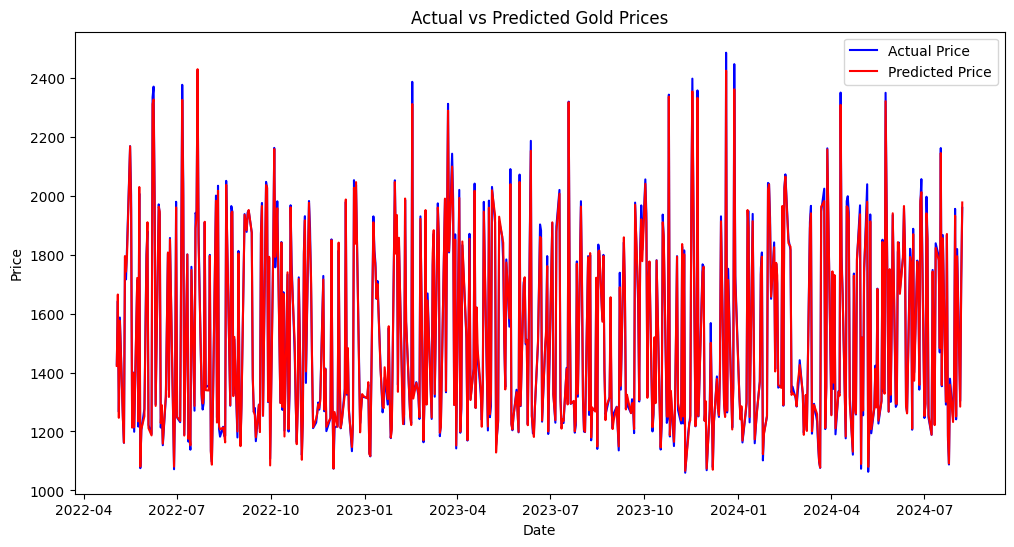

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Bidirectional, LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# Load the dataset
file_path = '/content/Gold Futures Historical Data.csv'
data = pd.read_csv(file_path)

# Data Preprocessing
def convert_volume(value):
    if isinstance(value, str):
        if 'K' in value:
            return float(value.replace('K', '')) * 1000
        elif 'M' in value:
            return float(value.replace('M', '')) * 1000000
        else:
            return float(value.replace(',', ''))
    return value  # If it's already a float

# Apply the conversion function to the 'Vol.' column
data['Vol.'] = data['Vol.'].apply(convert_volume)

# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Convert other columns to numeric
for col in ['Price', 'Open', 'High', 'Low']:
    data[col] = data[col].astype(str).str.replace(',', '', regex=False)
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Handle the 'Change %' column
data['Change %'] = data['Change %'].astype(str).str.strip().str.replace('%', '', regex=False)
data['Change %'] = pd.to_numeric(data['Change %'], errors='coerce')

# Handle missing values in 'Vol.' column
data['Vol.'].fillna(0, inplace=True)

# Drop rows with any remaining missing values
data.dropna(inplace=True)

# Sort by date
data.sort_values(by='Date', inplace=True)

# Feature Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Price', 'Open', 'High', 'Low', 'Vol.']])

# Create sequences for BLSTM model
X = []
y = []

window_size = 60

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i, 0])  # Predicting 'Price' column

X = np.array(X)
y = np.array(y)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape the data for BLSTM (already done by creating sequences)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Build BLSTM model
model = Sequential()

model.add(Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(units=50, return_sequences=True)))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(units=50)))
model.add(Dropout(0.2))

model.add(Dense(units=1))  # Output layer

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Model evaluation
y_pred = model.predict(X_test)

# Reverse the scaling for better interpretability
y_test_actual = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), X_test[:, -1, 1:]), axis=1))[:, 0]
y_pred_actual = scaler.inverse_transform(np.concatenate((y_pred, X_test[:, -1, 1:]), axis=1))[:, 0]

# Calculate performance metrics
mse = mean_squared_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

# Convert regression output to binary classification based on a threshold
price_threshold = np.median(y_test_actual)  # Threshold could be median or any chosen value
y_test_binary = (y_test_actual > price_threshold).astype(int)
y_pred_binary = (y_pred_actual > price_threshold).astype(int)

# Calculate classification metrics
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)
accuracy = accuracy_score(y_test_binary, y_pred_binary)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Accuracy: {accuracy}")

# Plot Actual vs Predicted values
plt.figure(figsize=(12, 6))
plt.plot(data['Date'][-len(y_test_actual):], y_test_actual, color='blue', label='Actual Price')
plt.plot(data['Date'][-len(y_pred_actual):], y_pred_actual, color='red', label='Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Actual vs Predicted Gold Prices')
plt.legend()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


X_train shape: (3952, 60, 5), y_train shape: (3952,)
X_test shape: (988, 60, 5), y_test shape: (988,)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional)      │ (None, 60, 100)             │          22,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 60, 100)             │          60,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 60, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 100)                 │          60,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 143,301 (559.77 KB)

 Trainable params: 143,301 (559.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0223 - val_loss: 5.9883e-04
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0023 - val_loss: 4.2686e-04
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0019 - val_loss: 4.0630e-04
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0016 - val_loss: 3.7919e-04
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0016 - val_loss: 6.0635e-04
Epoch 6/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0014 - val_loss: 3.8924e-04
Epoch 7/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0014 - val_loss: 2.6758e-04
Epoch 8/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0011 - val_loss: 9.6369e-04
Epoch 9/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0013 - val_loss: 9.0206e-04
Epoch 10/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0012 - val_loss: 2.2540e-04
Epoch 11/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0012 - val_los

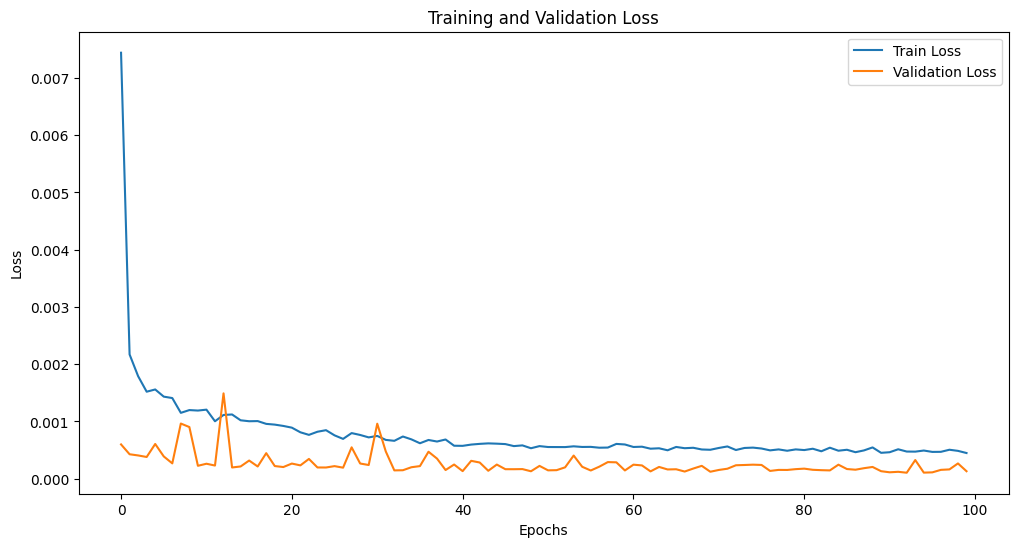

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Mean Squared Error: 349.42705655321635
R^2 Score: 0.9983300940587323
Precision: 1.0
Recall: 0.9959514170040485
F1 Score: 0.9979716024340771
Accuracy: 0.9979757085020243
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21m

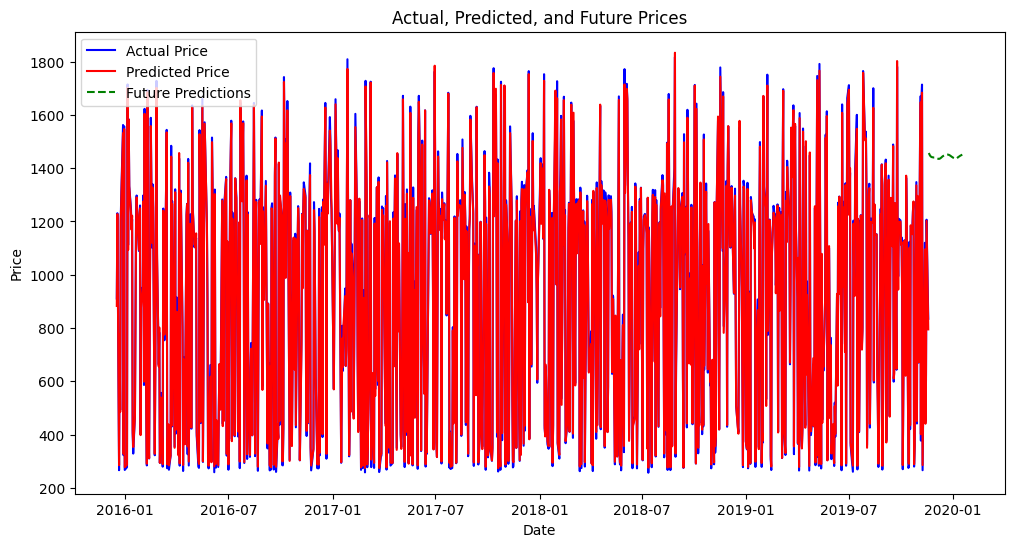

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Bidirectional, LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# Load the dataset
file_path = '/content/Gold Futures Historical Data.csv'
data = pd.read_csv(file_path)

# Data Preprocessing
def convert_volume(value):
    if isinstance(value, str):
        if 'K' in value:
            return float(value.replace('K', '')) * 1000
        elif 'M' in value:
            return float(value.replace('M', '')) * 1000000
        else:
            return float(value.replace(',', ''))
    return value  # If it's already a float

# Apply the conversion function to the 'Vol.' column
data['Vol.'] = data['Vol.'].apply(convert_volume)

# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Convert other columns to numeric
for col in ['Price', 'Open', 'High', 'Low']:
    data[col] = data[col].astype(str).str.replace(',', '', regex=False)
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Handle the 'Change %' column
data['Change %'] = data['Change %'].astype(str).str.strip().str.replace('%', '', regex=False)
data['Change %'] = pd.to_numeric(data['Change %'], errors='coerce')

# Handle missing values in 'Vol.' column
data['Vol.'].fillna(0, inplace=True)

# Drop rows with any remaining missing values
data.dropna(inplace=True)

# Sort by date
data.sort_values(by='Date', inplace=True)

# Feature Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Price', 'Open', 'High', 'Low', 'Vol.']])

# Create sequences for BLSTM model
X = []
y = []

window_size = 60

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i, 0])  # Predicting 'Price' column

X = np.array(X)
y = np.array(y)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape the data for BLSTM (already done by creating sequences)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Build BLSTM model
model = Sequential()

model.add(Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(units=50, return_sequences=True)))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(units=50)))
model.add(Dropout(0.2))

model.add(Dense(units=1))  # Output layer

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Model evaluation
y_pred = model.predict(X_test)

# Reverse the scaling for better interpretability
y_test_actual = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), X_test[:, -1, 1:]), axis=1))[:, 0]
y_pred_actual = scaler.inverse_transform(np.concatenate((y_pred, X_test[:, -1, 1:]), axis=1))[:, 0]

# Calculate performance metrics
mse = mean_squared_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

# Convert regression output to binary classification based on a threshold
price_threshold = np.median(y_test_actual)  # Threshold could be median or any chosen value
y_test_binary = (y_test_actual > price_threshold).astype(int)
y_pred_binary = (y_pred_actual > price_threshold).astype(int)

# Calculate classification metrics
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)
accuracy = accuracy_score(y_test_binary, y_pred_binary)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Accuracy: {accuracy}")

# Predict future prices for the next 60 days
# Create input sequence from the latest available data
last_sequence = scaled_data[-window_size:]

# Initialize future predictions array
future_predictions = []

for _ in range(60):
    # Reshape for model prediction
    last_sequence_reshaped = np.expand_dims(last_sequence, axis=0)
    future_price = model.predict(last_sequence_reshaped)

    # Append the prediction to the future_predictions list
    future_predictions.append(future_price[0, 0])

    # Update the sequence by appending the predicted price and removing the oldest data
    last_sequence = np.append(last_sequence[1:], [[future_price[0, 0], last_sequence[-1, 1], last_sequence[-1, 2], last_sequence[-1, 3], last_sequence[-1, 4]]], axis=0)

# Reverse scaling for future predictions
future_predictions_scaled = scaler.inverse_transform(np.concatenate((np.array(future_predictions).reshape(-1, 1), np.tile(scaled_data[-1, 1:], (60, 1))), axis=1))[:, 0]

# Plot Actual vs Predicted values and Future Predictions
plt.figure(figsize=(12, 6))
plt.plot(data['Date'][-len(y_test_actual):], y_test_actual, color='blue', label='Actual Price')
plt.plot(data['Date'][-len(y_pred_actual):], y_pred_actual, color='red', label='Predicted Price')
plt.plot(pd.date_range(start=data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=60, freq='D'), future_predictions_scaled, color='green', linestyle='--', label='Future Predictions')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Actual, Predicted, and Future Prices')
plt.legend()
plt.show()


In [ ]:
# Save the model
model.save('blstm_gold_price_model.h5')

In [ ]:
from keras.models import load_model

# Load the saved model
model = load_model('blstm_gold_price_model.h5')


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.9/82.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.0.0
    Uninstalling tenacity-9.0.0:
      Successfully uninstalled tenacity-9.0.0


In [ ]:
# %%writefile app.py
# import streamlit as st
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from keras.models import load_model
# from sklearn.preprocessing import MinMaxScaler

# # Load the model
# model = load_model('blstm_gold_price_model.h5')

# # Load the dataset to keep historical data for predictions
# file_path = '/content/Gold Futures Historical Data.csv'
# data = pd.read_csv(file_path)

# # Data Preprocessing (replicate the same steps)
# def preprocess_data(data):
#     def convert_volume(value):
#         if isinstance(value, str):
#             if 'K' in value:
#                 return float(value.replace('K', '')) * 1000
#             elif 'M' in value:
#                 return float(value.replace('M', '')) * 1000000
#             else:
#                 return float(value.replace(',', ''))
#         return value

#     data['Vol.'] = data['Vol.'].apply(convert_volume)
#     data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

#     for col in ['Price', 'Open', 'High', 'Low']:
#         data[col] = data[col].astype(str).str.replace(',', '', regex=False)
#         data[col] = pd.to_numeric(data[col], errors='coerce')

#     data['Change %'] = data['Change %'].astype(str).str.strip().str.replace('%', '', regex=False)
#     data['Change %'] = pd.to_numeric(data['Change %'], errors='coerce')

#     data['Vol.'].fillna(0, inplace=True)
#     data.dropna(inplace=True)
#     data.sort_values(by='Date', inplace=True)

#     return data

# data = preprocess_data(data)

# # Scaling the data
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(data[['Price', 'Open', 'High', 'Low', 'Vol.']])

# # Streamlit Interface
# st.title("Gold Price Prediction App")

# # User Input for custom feature selection
# window_size = st.slider("Select Window Size (Days):", 30, 120, 60)

# # Create the input sequence from the latest data
# last_sequence = scaled_data[-window_size:]

# # Predict Future Prices
# n_future_days = st.slider("Select Number of Future Days:", 1, 60, 30)
# future_predictions = []

# for _ in range(n_future_days):
#     last_sequence_reshaped = np.expand_dims(last_sequence, axis=0)
#     future_price = model.predict(last_sequence_reshaped)
#     future_predictions.append(future_price[0, 0])

#     last_sequence = np.append(last_sequence[1:], [[future_price[0, 0], last_sequence[-1, 1], last_sequence[-1, 2], last_sequence[-1, 3], last_sequence[-1, 4]]], axis=0)

# # Reverse scaling
# future_predictions_scaled = scaler.inverse_transform(
#     np.concatenate((np.array(future_predictions).reshape(-1, 1), np.tile(scaled_data[-1, 1:], (n_future_days, 1))), axis=1)
# )[:, 0]

# # Plotting Predictions
# st.subheader("Future Price Predictions")
# future_dates = pd.date_range(start=data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=n_future_days, freq='D')
# plt.figure(figsize=(10, 6))
# plt.plot(future_dates, future_predictions_scaled, label="Predicted Price", color='green')
# plt.xlabel('Date')
# plt.ylabel('Price')
# plt.title('Future Gold Price Predictions')
# plt.legend()
# st.pyplot(plt)


Overwriting app.py


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# Load the model
model = load_model('blstm_gold_price_model.h5')

# Load and preprocess the dataset
file_path = '/content/Gold Futures Historical Data.csv'
data = pd.read_csv(file_path)

# Data Preprocessing Function
def preprocess_data(data):
    def convert_volume(value):
        if isinstance(value, str):
            if 'K' in value:
                return float(value.replace('K', '')) * 1000
            elif 'M' in value:
                return float(value.replace('M', '')) * 1000000
            else:
                return float(value.replace(',', ''))
        return value

    data['Vol.'] = data['Vol.'].apply(convert_volume)
    data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

    for col in ['Price', 'Open', 'High', 'Low']:
        data[col] = data[col].astype(str).str.replace(',', '', regex=False)
        data[col] = pd.to_numeric(data[col], errors='coerce')

    data['Change %'] = data['Change %'].astype(str).str.strip().str.replace('%', '', regex=False)
    data['Change %'] = pd.to_numeric(data['Change %'], errors='coerce')

    data['Vol.'].fillna(0, inplace=True)
    data.dropna(inplace=True)
    data.sort_values(by='Date', inplace=True)

    return data

# Preprocess the data
data = preprocess_data(data)

# Initialize the scaler and scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Price', 'Open', 'High', 'Low', 'Vol.']])

# Streamlit App Interface
st.title("Gold Price Prediction App")

# Create two tabs: one for price prediction and another for future prediction
tab1, tab2 = st.tabs(["Price Prediction", "Future Prediction"])

# Tab 1: Price Prediction
with tab1:
    st.subheader("Price Prediction Based on Selected Features")

    # Feature selection
    selected_features = st.multiselect(
        "Select the features to use for prediction (Default: All):",
        options=['Open', 'High', 'Low', 'Vol.'],
        default=['Open', 'High', 'Low', 'Vol.']
    )

    # Ensure 'Price' is always part of the dataset for predictions, even if not selected
    all_features = ['Price'] + selected_features

    # Select a date range
    start_date = st.date_input("Start Date", value=pd.to_datetime(data['Date'].min()))
    end_date = st.date_input("End Date", value=pd.to_datetime(data['Date'].max()))

    # Filter data based on the selected date range
    filtered_data = data[(data['Date'] >= pd.to_datetime(start_date)) & (data['Date'] <= pd.to_datetime(end_date))]

    # Predict based on selected features
    if not filtered_data.empty:
        # Scale data only for selected features
        X_test = scaler.transform(filtered_data[all_features])

        # Create sequences for model input
        window_size = 60
        sequences = []
        for i in range(window_size, len(X_test)):
            sequences.append(X_test[i-window_size:i])

        if sequences:
            sequences = np.array(sequences)
            y_pred = model.predict(sequences)

            # Reverse scaling for predicted values, using only the 'Price' feature for inverse transform
            y_pred_actual = scaler.inverse_transform(
                np.concatenate((y_pred, np.zeros((y_pred.shape[0], X_test.shape[1] - 1))), axis=1)
            )[:, 0]

            # Plot results
            st.subheader("Predicted vs Actual Price")
            plt.figure(figsize=(10, 6))
            plt.plot(filtered_data['Date'][window_size:], y_pred_actual, label="Predicted Price", color='red')
            plt.plot(filtered_data['Date'][window_size:], filtered_data['Price'][window_size:], label="Actual Price", color='blue')
            plt.xlabel('Date')
            plt.ylabel('Price')
            plt.title('Predicted vs Actual Price')
            plt.legend()
            st.pyplot(plt)
        else:
            st.warning("Not enough data for prediction in the selected date range.")
    else:
        st.warning("No data available for the selected date range.")

# Tab 2: Future Price Prediction
with tab2:
    st.subheader("Future Price Prediction")

    # Select a window size and number of future days
    window_size = st.slider("Select Window Size (Days):", 30, 120, 60)
    n_future_days = st.slider("Select Number of Future Days:", 1, 120, 30)

    # Create the input sequence from the latest available data
    last_sequence = scaled_data[-window_size:, :]

    # Predict future prices
    future_predictions = []
    for _ in range(n_future_days):
        last_sequence_reshaped = np.expand_dims(last_sequence, axis=0)
        future_price = model.predict(last_sequence_reshaped)
        future_predictions.append(future_price[0, 0])

        # Update sequence with predicted price and preserve other feature values
        last_sequence = np.append(
            last_sequence[1:],
            [[future_price[0, 0], last_sequence[-1, 1], last_sequence[-1, 2], last_sequence[-1, 3], last_sequence[-1, 4]]],
            axis=0
        )

    # Reverse scaling for future predictions
    future_predictions_scaled = scaler.inverse_transform(
        np.concatenate((np.array(future_predictions).reshape(-1, 1), np.tile(scaled_data[-1, 1:], (n_future_days, 1))), axis=1)
    )[:, 0]

    # Plot future predictions
    future_dates = pd.date_range(start=data['Date'].iloc[-1] + pd.Timedelta(days=1), periods=n_future_days, freq='D')
    plt.figure(figsize=(10, 6))
    plt.plot(future_dates, future_predictions_scaled, label="Future Predicted Price", color='green')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Future Gold Price Predictions')
    plt.legend()
    st.pyplot(plt)


Overwriting app.py


In [ ]:
! wget -q -O - ipv4.icanhazip.com

35.240.189.252


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.189.252:8501

your url is: https://better-baboons-bake.loca.lt
2024-08-22 14:50:06.238075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-22 14:50:06.275018: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-22 14:50:06.286437: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-22 14:50:07.863081: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
I0000 00:00:172